# ✅ Step 5: Multivariate Plots
## 🎯 Goal:
### Visualize how more than 2 features interact.

#### 📊 Plots:
| Plot          | Use                            |
| ------------- | ------------------------------ |
| `pairplot()`  | Grid of pairwise scatter plots |
| `jointplot()` | 2D + distribution              |
| `heatmap()`   | Correlation matrix             |


# Pair plot
✅ What It Does
Plots scatterplots between every pair of numeric features

Adds histograms or KDE plots on the diagonal

Great for exploring relationships, patterns, clusters, and distributions quickly
```
syntax: sns.pairplot(data, hue=None, kind='scatter', diag_kind='auto', palette=None)
```

| Parameter     | Description                            |
| ------------- | -------------------------------------- |
| `data`        | DataFrame with numeric columns         |
| `hue`         | Grouping variable (color by category)  |
| `kind`        | `'scatter'` or `'kde'` (off-diagonal)  |
| `diag_kind`   | `'hist'` or `'kde'` (diagonal)         |
| `palette`     | Color palette                          |
| `corner=True` | Plot only lower triangle (saves space) |


c:\Users\mohda\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


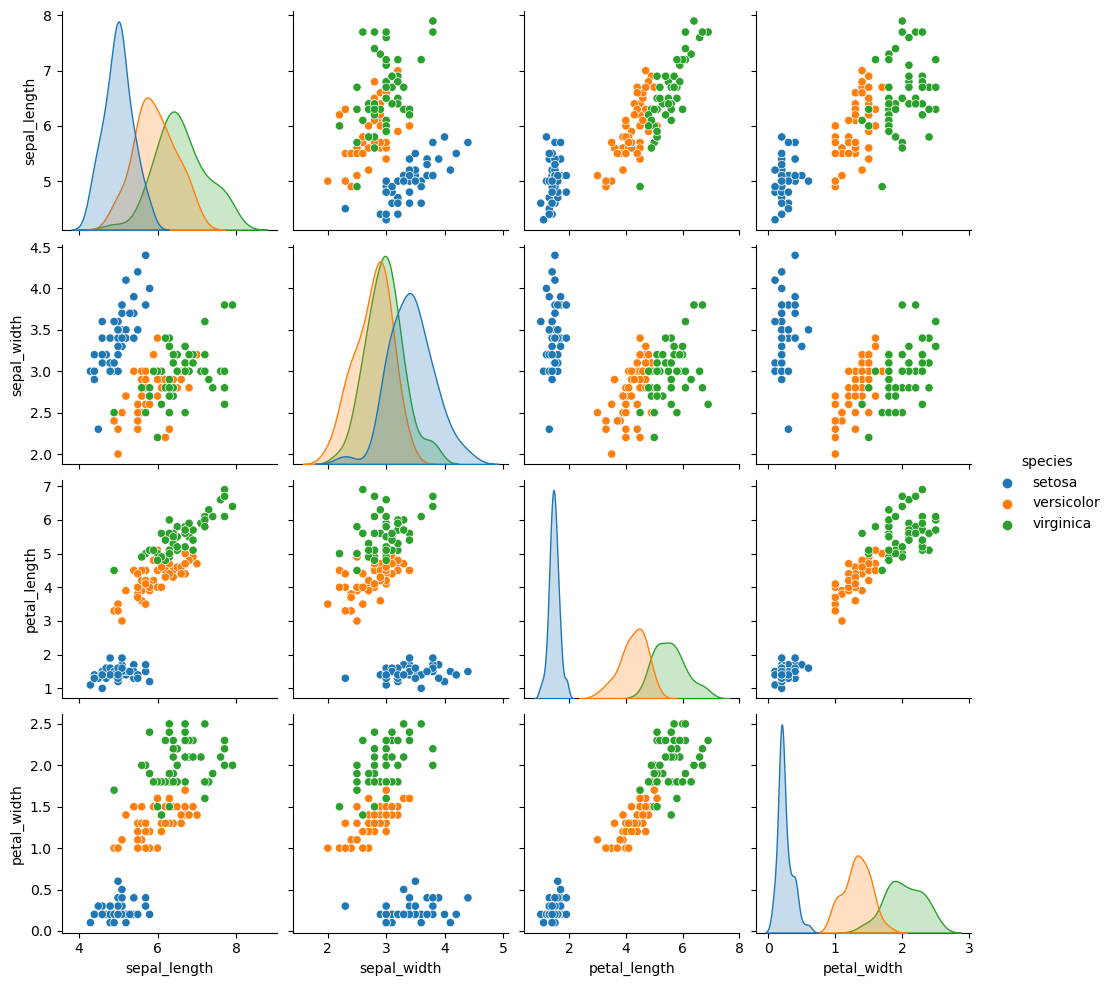

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from seaborn import load_dataset

iris = sns.load_dataset("iris")

sns.pairplot(iris, hue="species", diag_kind="kde")
plt.show()


c:\Users\mohda\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


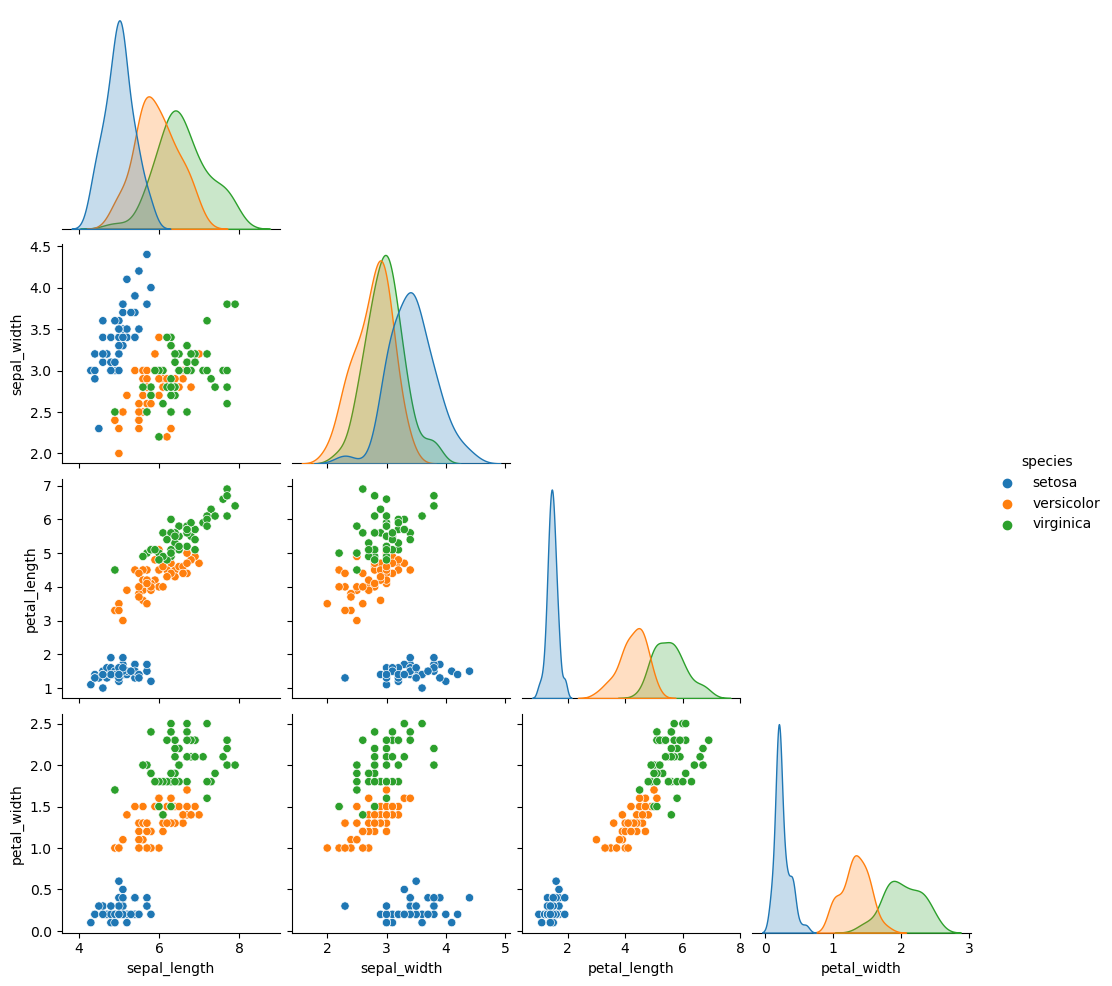

In [2]:
# 🔹 Only Lower Triangle
sns.pairplot(iris, hue="species", corner=True)


c:\Users\mohda\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


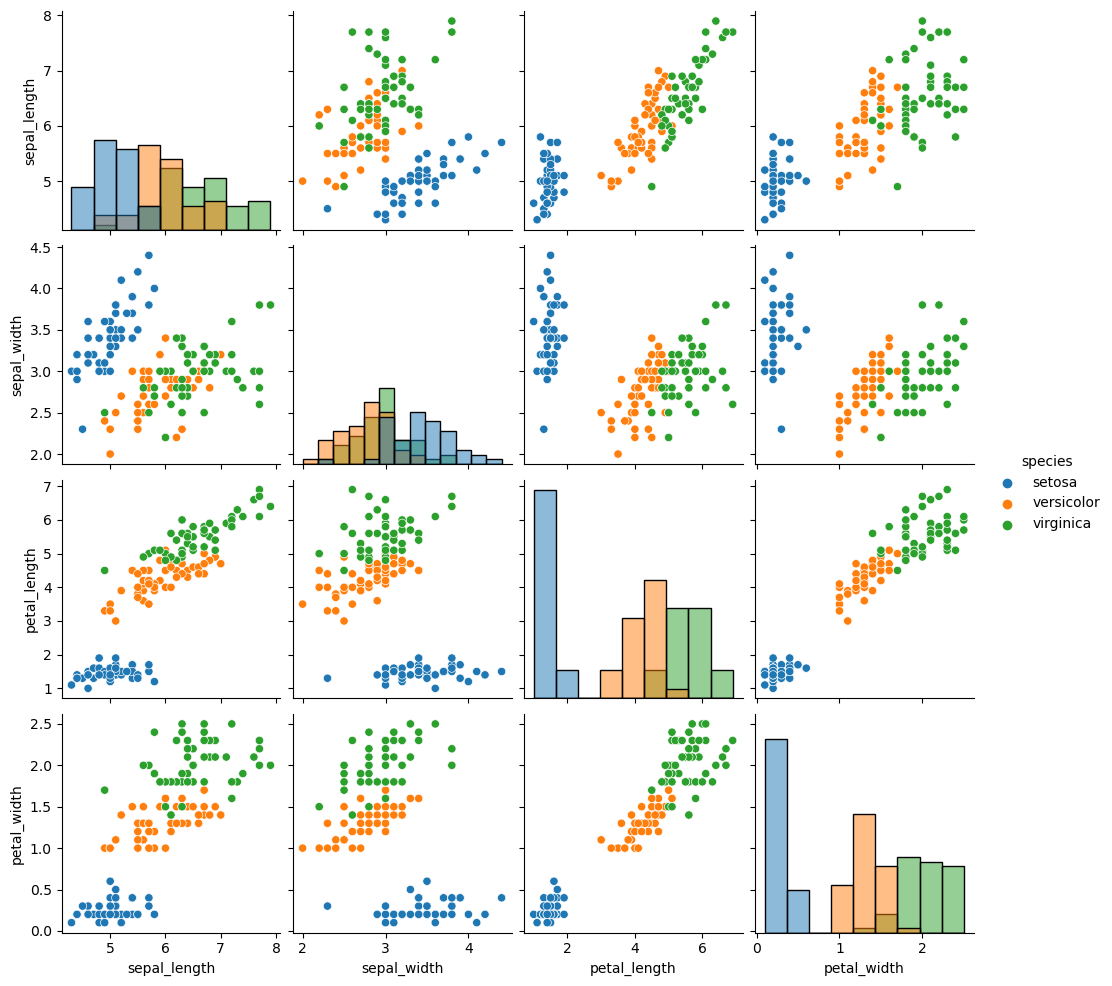

In [3]:
# 🔹 Use Histograms on Diagonal
sns.pairplot(iris, hue="species", diag_kind="hist")


c:\Users\mohda\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


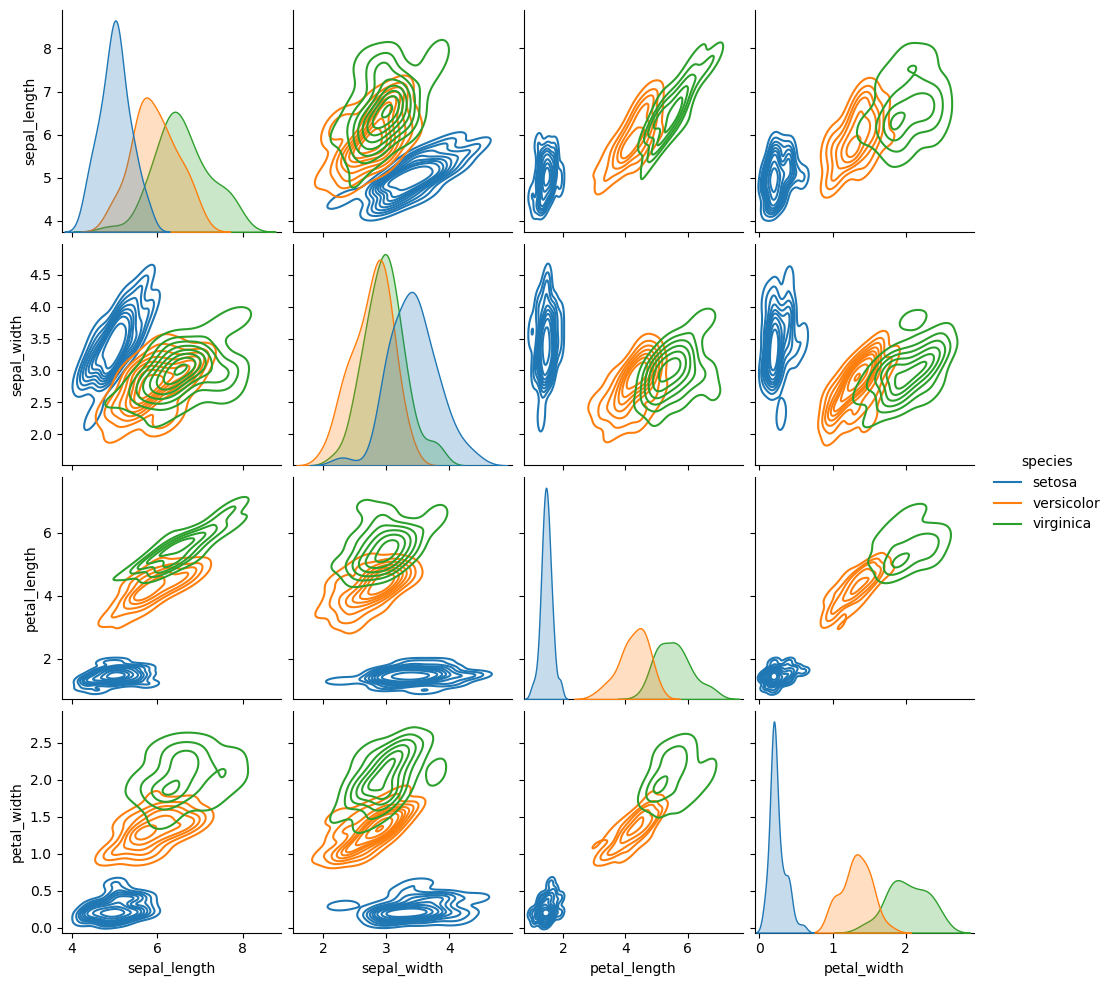

In [4]:
# 🔹 Change Plot Type to KDE
sns.pairplot(iris, kind="kde", hue="species")


# Joint Plot 
✅ What It Does
Combines a bivariate plot (scatter/hex/kde) with marginal distributions on top and right.

Shows how two variables are related along with their individual distributions.

```
sns.jointplot(x=None, y=None, data=None, kind='scatter', hue=None)
```

| Parameter | Description                                      |
| --------- | ------------------------------------------------ |
| `x`, `y`  | Variables to plot                                |
| `data`    | DataFrame                                        |
| `kind`    | `'scatter'`, `'kde'`, `'hex'`, `'reg'`, `'hist'` |
| `hue`     | Categorical column for coloring groups           |

Most Common Kind
| `kind`      | Description                           |
| ----------- | ------------------------------------- |
| `'scatter'` | Default. 2D scatter with histograms   |
| `'kde'`     | Smoothed joint + marginal KDEs        |
| `'hex'`     | Hexbin plot (good for dense data)     |
| `'reg'`     | Scatter with regression line          |
| `'hist'`    | Joint histogram                       |
| `'resid'`   | Residual plot (when using regression) |



  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


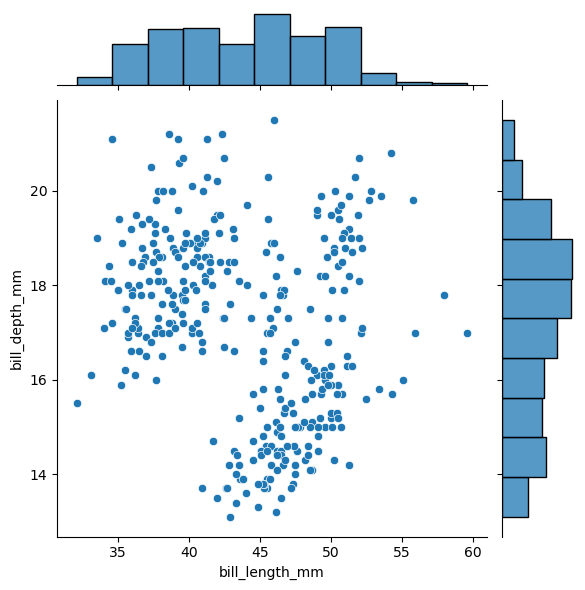

In [6]:
# ✅ Example 1: Basic Scatter + Marginals
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")
print(penguins.head())
sns.jointplot(x="bill_length_mm", y="bill_depth_mm", data=penguins, kind="scatter")
plt.show()


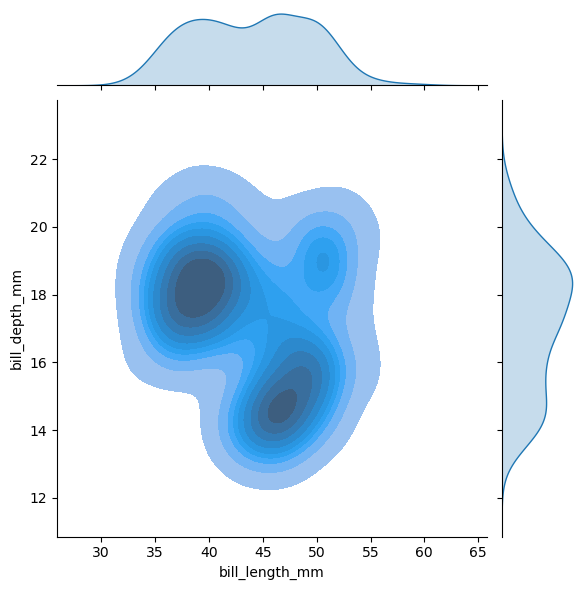

In [9]:
# ✅ Example 2: KDE Plot
sns.jointplot( x="bill_length_mm", y="bill_depth_mm", data=penguins, kind="kde",fill=True)


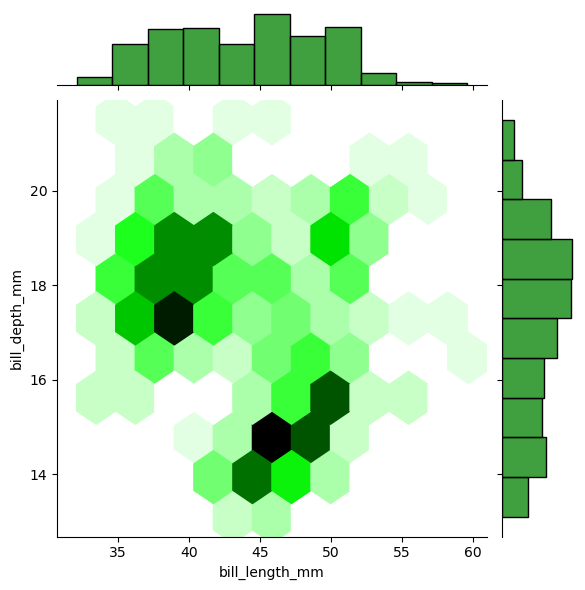

In [10]:
# ✅ Example 3: Hexbin Plot (for dense points)
sns.jointplot(
    x="bill_length_mm", y="bill_depth_mm", data=penguins, kind="hex", color="green"
)


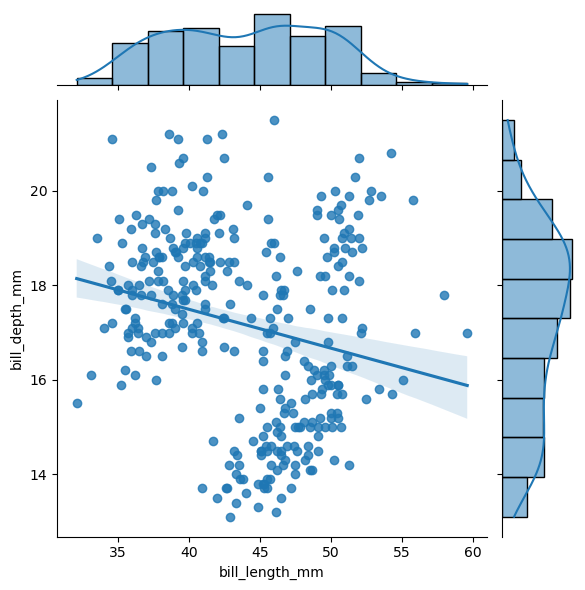

In [16]:
# ✅ Example 4: Regression Line
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
penguins = sns.load_dataset("penguins")

# Drop rows with missing values (penguins dataset has NaNs)
penguins = penguins.dropna()

# Create jointplot
sns.jointplot(
    x="bill_length_mm",
    y="bill_depth_mm",
    data=penguins,
    kind="reg"
)

plt.show()
# Drop rows with missing values (penguins dataset has NaNs)
penguins = penguins.dropna()




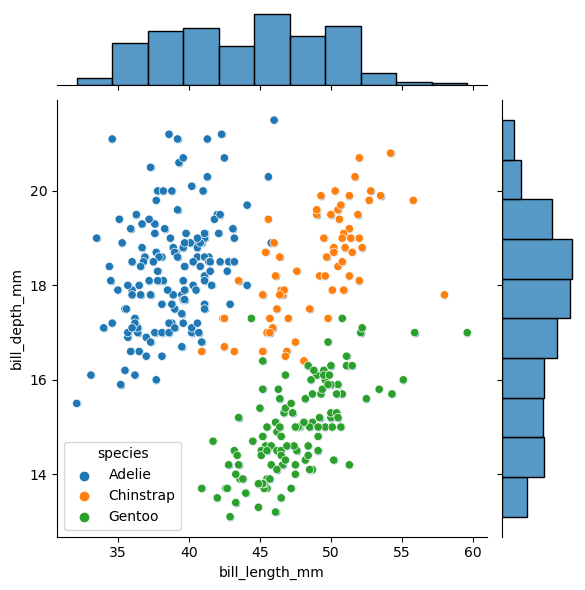

In [17]:
# 🛠️ Extra Customization
g = sns.jointplot(x="bill_length_mm", y="bill_depth_mm", data=penguins)
g.plot_joint(sns.scatterplot, hue=penguins["species"])



# Heatmap
✅ What It Does
Creates a colored matrix where color intensity shows the magnitude of values

Commonly used to visualize:

Correlation matrices

Confusion matrices

Any 2D numerical matrix

```
sns.heatmap(data, annot=False, cmap=None, linewidths=0, linecolor='white', fmt='.2g')
```

| Parameter      | Description                                                 |
| -------------- | ----------------------------------------------------------- |
| `data`         | 2D DataFrame or matrix (usually numeric)                    |
| `annot`        | Show actual values in each cell (`True`/`False`)            |
| `fmt`          | String formatting for annotations (e.g., ".2f")             |
| `cmap`         | Color palette (e.g., `"coolwarm"`, `"viridis"`, `"YlGnBu"`) |
| `linewidths`   | Gap lines between cells                                     |
| `linecolor`    | Color of those lines                                        |
| `vmin`, `vmax` | Fix min and max scale (useful for comparison)               |

🧠 Tips
Always use .dropna() before correlation to avoid errors

Use annot=True to show values on the grid

cmap choice helps guide the interpretation





  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  


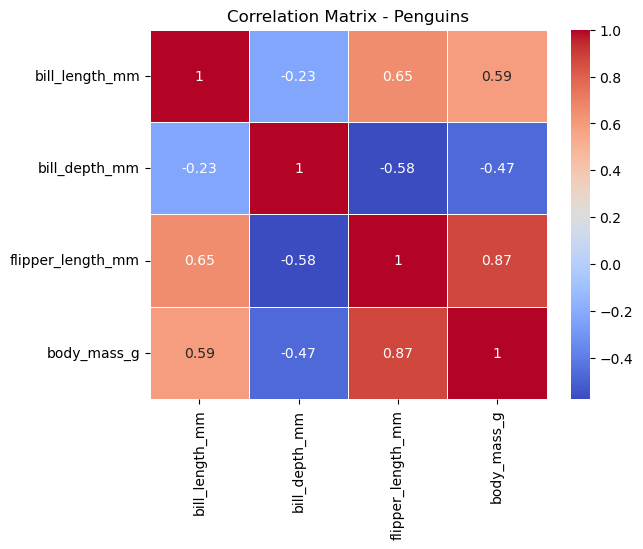

In [19]:
# ✅ Example: Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("penguins")
df = df.dropna()  # Drop NaNs
print(df.head())
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5, linecolor="white")

plt.title("Correlation Matrix - Penguins")
plt.show()


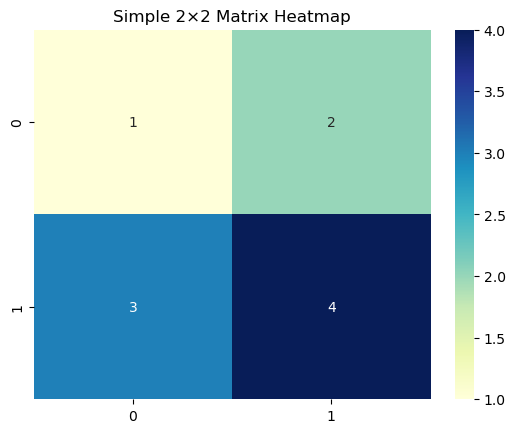

In [20]:
# ✅ Example 2: Simple Matrix
import numpy as np

data = np.array([[1, 2], [3, 4]])
sns.heatmap(data, annot=True, cmap="YlGnBu")
plt.title("Simple 2×2 Matrix Heatmap")
plt.show()


# 🎨 Popular Color Maps (cmap options):

| Palette      | Description                  |
| ------------ | ---------------------------- |
| `"coolwarm"` | Good for diverging values    |
| `"viridis"`  | Smooth, perceptually uniform |
| `"YlGnBu"`   | Yellow → Green → Blue        |
| `"magma"`    | Dark to light (bright magma) |
| `"rocket"`   | Light red to dark gray       |
